In [41]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

In [42]:
IMAZE_SIZE = 256
BATCH_SIZE = 32
CHHANNELS = 3
EPOCHs = 10

In [43]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    'Dataset',
    shuffle = True,
    image_size = (IMAZE_SIZE, IMAZE_SIZE),
    batch_size = BATCH_SIZE
)

Found 35725 files belonging to 23 classes.


In [44]:
len(dataset)

1117

In [45]:
1117*32

35744

In [46]:
class_names = dataset.class_names
class_names

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Pepper__bell___Bacterial_spot',
 'Pepper__bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato__Target_Spot',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_healthy']

In [47]:
for image_batch, label_batch in dataset.take(1):
    print(image_batch.shape)
    print(label_batch.shape)

(32, 256, 256, 3)
(32,)


In [48]:
for class_names in dataset

SyntaxError: expected ':' (3838895039.py, line 1)

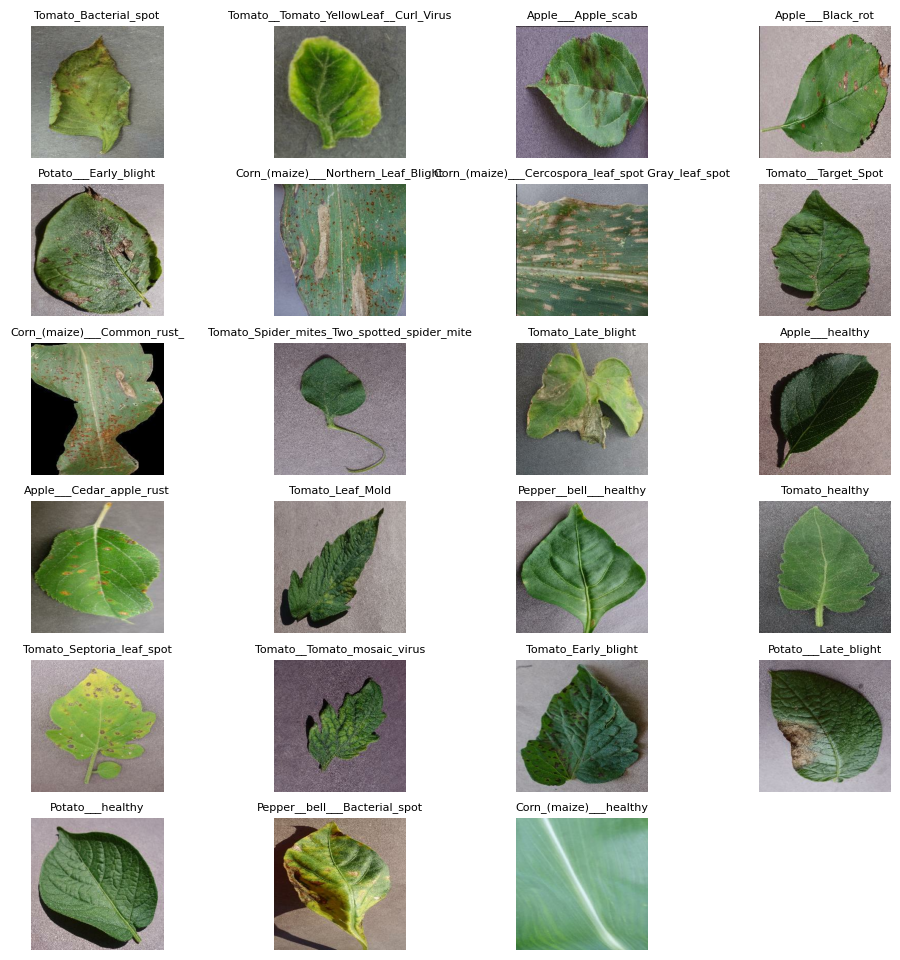

In [ ]:
seen = {}

for images, labels in dataset:
    for img, lbl in zip(images, labels):
        lbl = int(lbl)
        if lbl not in seen:
            seen[lbl] = img.numpy()
        if len(seen) == len(class_names):
            break
    if len(seen) == len(class_names):
        break

plt.figure(figsize=(12, 12))
for i, (lbl, img) in enumerate(seen.items()):
    plt.subplot(6, 4, i+1)
    plt.imshow(img.astype("uint8"))
    plt.title(class_names[lbl], fontsize=8)
    plt.axis("off")

plt.show()

In [ ]:
# train_size = 0.8
# test_size = 0.1
# val_size = 0.1

# len(dataset)*train_size

# train_ds = dataset.take(893)
# len(train_ds)

# test_ds = dataset.skip(893)
# val_ds = test_ds.take(100)
# test_ds = test_ds.skip(100)

In [ ]:
def dataset_partition(ds, train_split = 0.8, test_split = 0.1, val_split = 0.1, shuffle=True, shuffle_size=10000):
    
    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, test_ds, val_ds

In [ ]:
train_ds, test_ds, val_ds = dataset_partition(dataset)

In [ ]:
print(len(dataset))
print(len(train_ds))
print(len(test_ds))
print(len(val_ds))

1117
893
113
111


In [49]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

In [52]:
resize_rescale = tf.keras.Sequential([
    layers.Resizing(IMAZE_SIZE, IMAZE_SIZE),
    layers.Rescaling(1.0/255)
])

In [53]:
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
])

In [ ]:
input_shape = (BATCH_SIZE, IMAZE_SIZE, IMAZE_SIZE, CHHANNELS)
n_classes = 23

model = models.Sequential([
    resize_rescale,
    data_augmentation,
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

model.build(input_shape=input_shape)